## 注意力评分函数

上一节使用了高斯核来对查询和键之间的关系建模。高斯核指数部分可以视为注意力评分函数（attention scoring function）， 简称评分函数（scoring function）， 然后把这个函数的输出结果输入到softmax函数中进行运算。 通过上述步骤，将得到与键对应的值的概率分布（即注意力权重）。 最后，注意力汇聚的输出就是基于这些注意力权重的值的加权和。

从宏观来看，上述算法可以用来实现下图中的注意力机制框架。下图说明了 如何将注意力汇聚的输出计算成为值的加权和，其中$a$表示注意力评分函数。
由于注意力权重是概率分布，因此加权和其本质上是加权平均值

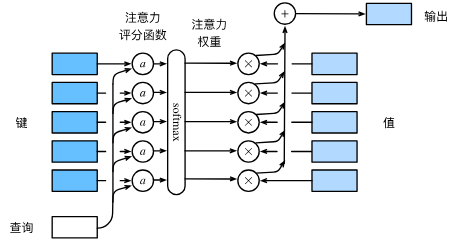

用数学语言描述，假设有一个查询
$\mathbf{q} \in \mathbb{R}^q$和
$m$个“键－值”对
$(\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)$，
其中$\mathbf{k}_i \in \mathbb{R}^k$，$\mathbf{v}_i \in \mathbb{R}^v$。
注意力汇聚函数$f$就被表示成值的加权和：

$$f(\mathbf{q}, (\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)) = \sum_{i=1}^m \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i \in \mathbb{R}^v,$$
其中查询$\mathbf{q}$和键$\mathbf{k}_i$的注意力权重（标量）
是通过注意力评分函数$a$将两个向量映射成标量，
再经过softmax运算得到的：

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}(a(\mathbf{q}, \mathbf{k}_i)) = \frac{\exp(a(\mathbf{q}, \mathbf{k}_i))}{\sum_{j=1}^m \exp(a(\mathbf{q}, \mathbf{k}_j))} \in \mathbb{R}.$$

正如上图所示，选择不同的注意力评分函数$a$会导致不同的注意力汇聚操作。
本节将介绍两个流行的评分函数，稍后将用他们来实现更复杂的注意力机制。

In [1]:
import math
import torch
from torch import nn
from d2l import torch as d2l

### 遮蔽softmax操作

正如上面提到的，softmax操作用于输出一个概率分布作为注意力权重。 在某些情况下，并非所有的值都应该被纳入到注意力汇聚中。为了仅将有意义的词元作为值来获取注意力汇聚， 可以指定一个有效序列长度（即词元的个数）， 以便在计算softmax时过滤掉超出指定范围的位置。 下面的masked_softmax函数 实现了这样的掩蔽softmax操作（masked softmax operation）， 其中任何超出有效长度的位置都被掩蔽并置为0。

In [2]:
def masked_softmax(X,valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    # X:3D张量，valid_lens:1D或2D张量
    if valid_lens is None:
        return nn.functional.softmax(X,dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens,shape[1]) # 与X的第二维匹配
        else:
            valid_lens = valid_lens.reshape(-1) # 若是二维张量，则将其展平为一维。
        # 最后一轴上被掩蔽的元素使用一个非常大的负值替换，从而其softmax输出为0
        X = d2l.sequence_mask(X.reshape(-1,shape[-1]),valid_lens,value=-1e6)
        return nn.functional.softmax(X.reshape(shape),dim=-1)

为了演示此函数是如何工作的， 考虑由两个2x4矩阵表示的样本， 这两个样本的有效长度分别为2和3。 经过掩蔽softmax操作，超出有效长度的值都被掩蔽为0。

In [6]:
masked_softmax(torch.randn(2,2,4),torch.tensor([2,3]))

tensor([[[0.7632, 0.2368, 0.0000, 0.0000],
         [0.8332, 0.1668, 0.0000, 0.0000]],

        [[0.7569, 0.1535, 0.0896, 0.0000],
         [0.2208, 0.5956, 0.1836, 0.0000]]])

### 加性注意力

一般来说，当查询和键是不同长度的矢量时，可以使用加性注意力作为评分函数。
给定查询$\mathbf{q} \in \mathbb{R}^q$和
键$\mathbf{k} \in \mathbb{R}^k$，
*加性注意力*（additive attention）的评分函数为

$$a(\mathbf q, \mathbf k) = \mathbf w_v^\top \text{tanh}(\mathbf W_q\mathbf q + \mathbf W_k \mathbf k) \in \mathbb{R},$$
其中可学习的参数是$\mathbf W_q\in\mathbb R^{h\times q}$、
$\mathbf W_k\in\mathbb R^{h\times k}$和
$\mathbf w_v\in\mathbb R^{h}$。如上所示将查询和键连结起来后输入到一个多层感知机（MLP）中，
感知机包含一个隐藏层，其隐藏单元数是一个超参数$h$。
通过使用$\tanh$作为激活函数，并且禁用偏置项。

下面来实现加性注意力。


In [9]:
class AddtiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self,key_size,query_size,num_hiddens,dropout,**kwargs):
        super(AddtiveAttention,self).__init__(**kwargs)
        self.W_q = nn.Linear(query_size,num_hiddens,bias=False)
        self.W_k = nn.Linear(key_size,num_hiddens,bias=False)
        self.W_v = nn.Linear(num_hiddens,1,bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self,queries,keys,values,valid_lens):
        queries,keys = self.W_q(queries),self.W_k(keys)
        # 在维度扩展后，
        # queries的形状：(batch_size，查询的个数，1，num_hidden)
        # key的形状：(batch_size，1，“键－值”对的个数，num_hiddens)
        # 使用广播方式进行求和
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # self.w_v仅有一个输出，因此从形状中移除最后那个维度。
        # scores的形状：(batch_size，查询的个数，“键-值”对的个数)
        scores = self.W_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores,valid_lens)
        # values的形状：(batch_size，“键－值”对的个数，值的维度)
        return torch.bmm(self.dropout(self.attention_weights),values)

用一个小例子来[**演示上面的`AdditiveAttention`类**]，
其中查询、键和值的形状为（批量大小，步数或词元序列长度，特征大小），
实际输出为$(2,1,20)$、$(2,10,2)$和$(2,10,4)$。
注意力汇聚输出的形状为（批量大小，查询的步数，值的维度）。


In [10]:
queries,keys = torch.normal(0,1,(2,1,20)),torch.ones((2,10,2))
# values的小批量，两个值矩阵是相同的
values = torch.arange(40,dtype=torch.float32).reshape(1,10,4).repeat(2,1,1) # 在第一个维度上重复 2 次。在第二个维度上重复 1 次。在第三个维度上重复 1 次。
valid_lens = torch.tensor([2,6])

attention = AddtiveAttention(key_size=2,query_size=20,num_hiddens=8,dropout=0.1)
attention.eval()
attention(queries,keys,values,valid_lens)


tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], grad_fn=<BmmBackward0>)

尽管加性注意力包含了可学习的参数，但由于本例子中每个键都是相同的， 所以注意力权重是均匀的，由指定的有效长度决定。

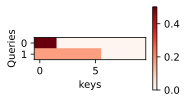

In [11]:
d2l.show_heatmaps(attention.attention_weights.reshape((1,1,2,10)),xlabel='keys',ylabel='Queries')

### 缩放点积注意力

使用点积可以得到计算效率更高的评分函数，
但是点积操作要求查询和键具有相同的长度$d$。
假设查询和键的所有元素都是独立的随机变量，
并且都满足零均值和单位方差，
那么两个向量的点积的均值为$0$，方差为$d$。
为确保无论向量长度如何，
点积的方差在不考虑向量长度的情况下仍然是$1$，
我们再将点积除以$\sqrt{d}$，
则*缩放点积注意力*（scaled dot-product attention）评分函数为：

$$a(\mathbf q, \mathbf k) = \mathbf{q}^\top \mathbf{k}  /\sqrt{d}.$$

在实践中，我们通常从小批量的角度来考虑提高效率，
例如基于$n$个查询和$m$个键－值对计算注意力，
其中查询和键的长度为$d$，值的长度为$v$。
查询$\mathbf Q\in\mathbb R^{n\times d}$、
键$\mathbf K\in\mathbb R^{m\times d}$和
值$\mathbf V\in\mathbb R^{m\times v}$的缩放点积注意力是：

$$ \mathrm{softmax}\left(\frac{\mathbf Q \mathbf K^\top }{\sqrt{d}}\right) \mathbf V \in \mathbb{R}^{n\times v}.$$

下面的缩放点积注意力的实现使用了暂退法进行模型正则化。


In [12]:
class DotProductAttetion(nn.Module):
    """缩放点积注意力"""
    def __init__(self,dropout,**kwargs):
        super(DotProductAttetion,self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # queries的形状：(batch_size，查询的个数，d)
    # keys的形状：(batch_size，“键－值”对的个数，d)
    # values的形状：(batch_size，“键－值”对的个数，值的维度)
    # valid_lens的形状:(batch_size，)或者(batch_size，查询的个数)
    def forward(self,queries,keys,values,valid_lens=None):
        d = queries.shape[-1]
        # 设置transpose_b = True为了交换keys的最后两个维度
        scores = torch.bmm(queries,keys.transpose(1,2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores,valid_lens)
        return torch.bmm(self.dropout(self.attention_weights),values)


为了演示上述的DotProductAttention类， 我们使用与先前加性注意力例子中相同的键、值和有效长度。 对于点积操作，我们令查询的特征维度与键的特征维度大小相同。

In [13]:
queries = torch.normal(0,1,(2,1,2))
attention = DotProductAttetion(dropout=0.5)
attention.eval()
attention(queries,keys,values,valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]])

与加性注意力演示相同，由于键包含的是相同的元素， 而这些元素无法通过任何查询进行区分，因此获得了均匀的注意力权重。

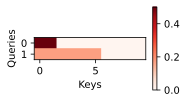

In [14]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

### 小结

将注意力汇聚的输出计算可以作为值的加权平均，选择不同的注意力评分函数会带来不同的注意力汇聚操作。

当查询和键是不同长度的矢量时，可以使用可加性注意力评分函数。当它们的长度相同时，使用缩放的“点－积”注意力评分函数的计算效率更高。